# 🏎️ F1 Pit Stop Prediction — Notebook 3: Baseline Model
**Kaggle Playground Series S6E5**

Strategy:
- LightGBM classifier with group-aware cross-validation (split by Race+Year)
- 2023 handled explicitly — included but flagged, CV folds respect its anomaly
- Evaluation metric: AUC (ROC)
- Output: first submission file

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR  = Path('data')
SUBM_DIR  = Path('submissions')
SUBM_DIR.mkdir(exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train_cleaned.csv')
test  = pd.read_csv(DATA_DIR / 'test_cleaned.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

with open(DATA_DIR / 'feature_list.json') as f:
    meta = json.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target: {TARGET}')

Train: (416326, 26), Test: (188165, 25)
Features (22): ['TyreLife', 'TyreLifeRatio', 'TyreOverdue', 'CompoundMedianLife', 'Compound_ord', 'LapNumber', 'RaceProgress', 'LapsRemaining', 'TotalLaps', 'Stint', 'StintCapped', 'IsStint2', 'LapTime (s)', 'Cumulative_Degradation', 'Position_Change', 'Position', 'IsFinalLaps', 'IsFirstLap', 'Is2023', 'IsStreetCircuit', 'Race_enc', 'Year']
Target: PitNextLap


## 1. Cross-Validation Strategy

In [2]:
# Group CV: split by Race+Year — no lap from the same race appears in both train and val
# This prevents the model from memorising race-level patterns and gives honest AUC estimates
# We use GroupKFold with 5 folds

# Create group key: each unique Race+Year combo is one group
train['group'] = train['Race'] + '_' + train['Year'].astype(str)
groups = train['group']

n_groups = groups.nunique()
print(f'Total Race+Year groups: {n_groups}')
print(f'Approximate group size: {len(train) // n_groups} rows per group')

# Show fold composition
gkf = GroupKFold(n_splits=5)
for fold, (tr_idx, val_idx) in enumerate(gkf.split(train, train[TARGET], groups)):
    val_groups = groups.iloc[val_idx].unique()
    val_2023 = sum('2023' in g for g in val_groups)
    print(f'Fold {fold+1}: {len(tr_idx):>6} train | {len(val_idx):>6} val | '
          f'{len(val_groups):>2} races | 2023 races: {val_2023}')

Total Race+Year groups: 90
Approximate group size: 4625 rows per group
Fold 1: 332965 train |  83361 val | 18 races | 2023 races: 3
Fold 2: 332895 train |  83431 val | 18 races | 2023 races: 6
Fold 3: 332955 train |  83371 val | 18 races | 2023 races: 3
Fold 4: 333332 train |  82994 val | 18 races | 2023 races: 5
Fold 5: 333157 train |  83169 val | 18 races | 2023 races: 5


## 2. Baseline LightGBM — Parameters

In [3]:
# Conservative baseline params — no tuning yet
# scale_pos_weight handles class imbalance (~80/20)
neg_count = (train[TARGET] == 0).sum()
pos_count = (train[TARGET] == 1).sum()
spw = neg_count / pos_count
print(f'Class ratio (neg/pos): {spw:.2f} → scale_pos_weight={spw:.2f}')

PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'learning_rate':    0.05,
    'n_estimators':     1000,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     1,
    'scale_pos_weight': spw,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'verbose':          -1,
    'n_jobs':           -1,
}

Class ratio (neg/pos): 3.96 → scale_pos_weight=3.96


## 3. Cross-Validated Training

In [4]:
X = train[FEATURES]
y = train[TARGET]

oof_preds   = np.zeros(len(train))
test_preds  = np.zeros(len(test))
fold_scores = []
fold_models = []

gkf = GroupKFold(n_splits=5)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    fold_models.append(model)

    # Accumulate test predictions
    test_preds += model.predict_proba(test[FEATURES])[:, 1] / 5

    print(f'Fold {fold+1} | best_iter={model.best_iteration_:>4} | AUC={fold_auc:.5f}')

overall_auc = roc_auc_score(y, oof_preds)
print(f'\nOOF AUC:  {overall_auc:.5f}')
print(f'Mean CV:  {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')

[100]	valid_0's auc: 0.901916
[200]	valid_0's auc: 0.903639
[300]	valid_0's auc: 0.904406
[400]	valid_0's auc: 0.904581
Fold 1 | best_iter= 361 | AUC=0.90468
[100]	valid_0's auc: 0.930688
[200]	valid_0's auc: 0.931407
Fold 2 | best_iter= 217 | AUC=0.93156
[100]	valid_0's auc: 0.911715
Fold 3 | best_iter=  94 | AUC=0.91216
[100]	valid_0's auc: 0.93784
[200]	valid_0's auc: 0.938678
Fold 4 | best_iter= 224 | AUC=0.93909
[100]	valid_0's auc: 0.922199
Fold 5 | best_iter=  63 | AUC=0.92257

OOF AUC:  0.92130
Mean CV:  0.92201 ± 0.01249


## 4. OOF Analysis

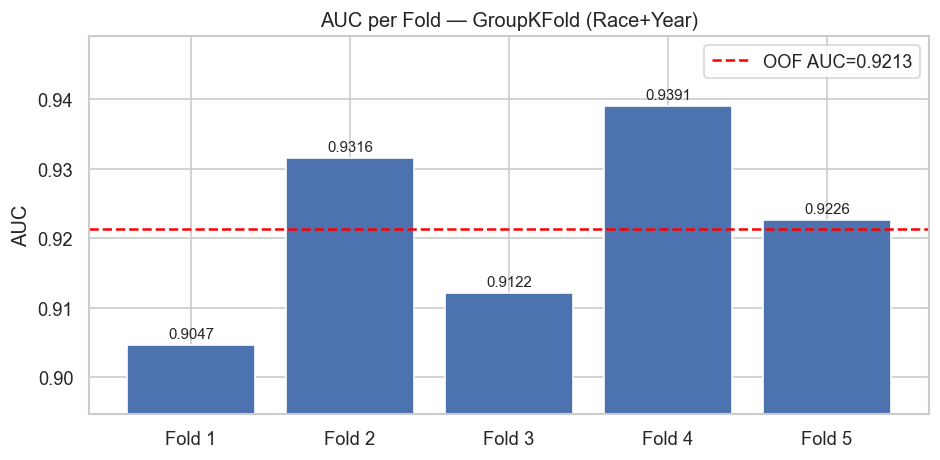

In [5]:
# Fold scores
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(5)], fold_scores, color='#4C72B0')
ax.axhline(overall_auc, color='red', linestyle='--', label=f'OOF AUC={overall_auc:.4f}')
ax.set_ylim(min(fold_scores) - 0.01, max(fold_scores) + 0.01)
ax.set_title('AUC per Fold — GroupKFold (Race+Year)')
ax.set_ylabel('AUC')
ax.legend()
for bar, score in zip(bars, fold_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# AUC broken down by year — reveals 2023 impact
train['oof_pred'] = oof_preds
print('OOF AUC by year:')
for year in sorted(train['Year'].unique()):
    mask = train['Year'] == year
    if train.loc[mask, TARGET].nunique() > 1:
        auc = roc_auc_score(train.loc[mask, TARGET], train.loc[mask, 'oof_pred'])
        pit_rate = train.loc[mask, TARGET].mean()
        print(f'  {year}: AUC={auc:.5f}  pit_rate={pit_rate:.2%}  n={mask.sum()}')

OOF AUC by year:
  2022: AUC=0.87889  pit_rate=25.72%  n=77613
  2023: AUC=0.82663  pit_rate=0.99%  n=128242
  2024: AUC=0.88232  pit_rate=30.32%  n=121804
  2025: AUC=0.89449  pit_rate=29.13%  n=88667


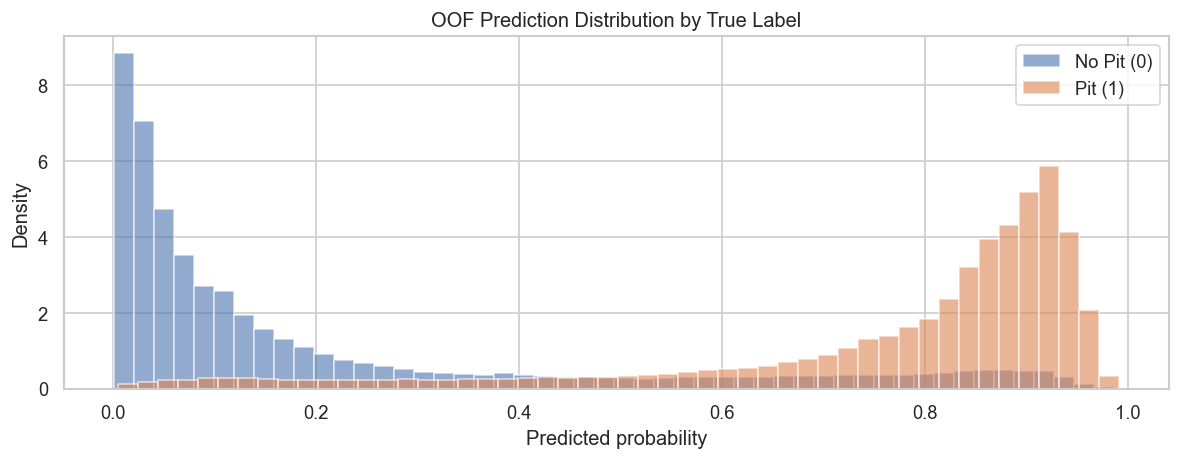

In [7]:
# OOF prediction distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oof_preds[y == 0], bins=50, alpha=0.6, label='No Pit (0)', 
        color='#4C72B0', density=True)
ax.hist(oof_preds[y == 1], bins=50, alpha=0.6, label='Pit (1)', 
        color='#DD8452', density=True)
ax.set_title('OOF Prediction Distribution by True Label')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance

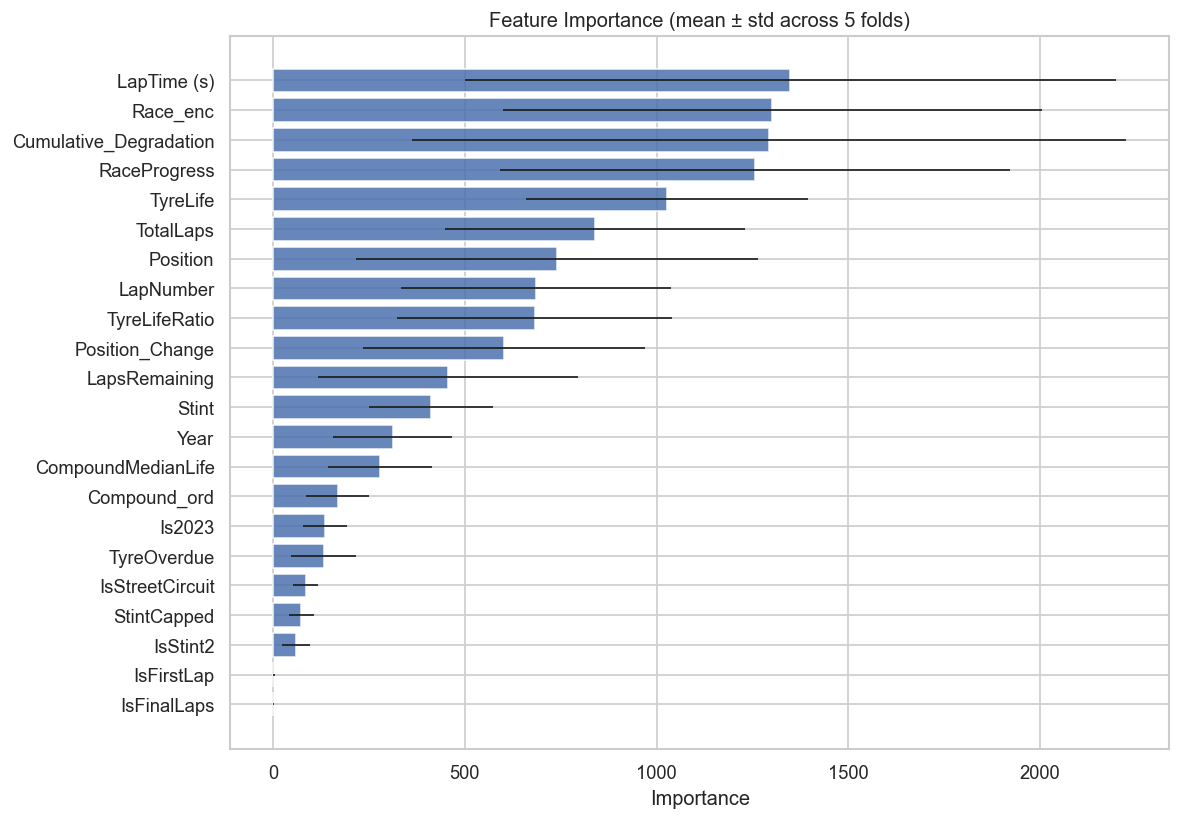


Top 10 features:
                            mean      std
LapTime (s)            1348.8000 849.8000
Race_enc               1301.8000 703.8000
Cumulative_Degradation 1293.6000 930.8000
RaceProgress           1257.2000 665.3000
TyreLife               1027.2000 367.4000
TotalLaps               839.2000 391.5000
Position                741.0000 524.0000
LapNumber               685.4000 353.3000
TyreLifeRatio           681.6000 357.6000
Position_Change         601.4000 367.3000

Bottom 5 features (candidates for removal):
                   mean     std
IsStreetCircuit 84.8000 32.9000
StintCapped     73.6000 32.6000
IsStint2        60.0000 37.2000
IsFirstLap       2.6000  2.3000
IsFinalLaps      0.6000  0.8000


In [8]:
# Average importance across all 5 folds
imp_df = pd.DataFrame({
    f'fold_{i+1}': fold_models[i].feature_importances_
    for i in range(5)
}, index=FEATURES)

imp_df['mean'] = imp_df.mean(axis=1)
imp_df['std']  = imp_df.std(axis=1)
imp_df = imp_df.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df.index, imp_df['mean'], xerr=imp_df['std'],
        color='#4C72B0', alpha=0.85, error_kw={'linewidth': 1})
ax.invert_yaxis()
ax.set_title('Feature Importance (mean ± std across 5 folds)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(imp_df[['mean', 'std']].head(10).round(1))
print('\nBottom 5 features (candidates for removal):')
print(imp_df[['mean', 'std']].tail(5).round(1))

## 6. OOF AUC Without 2023

In [9]:
# The 2023 anomaly (0.99% pit rate) will distort OOF AUC
# Report both — OOF overall and OOF excluding 2023 — to understand true signal
mask_non2023 = train['Year'] != 2023
auc_non2023 = roc_auc_score(
    train.loc[mask_non2023, TARGET],
    train.loc[mask_non2023, 'oof_pred']
)
print(f'OOF AUC (all years):     {overall_auc:.5f}')
print(f'OOF AUC (excl. 2023):    {auc_non2023:.5f}')
print(f'Difference:               {auc_non2023 - overall_auc:+.5f}')
print()
print('Note: the Kaggle leaderboard score reflects the test set which includes')
print('2023 rows (31% of test). Track both metrics through the competition.')

OOF AUC (all years):     0.92130
OOF AUC (excl. 2023):    0.88551
Difference:               -0.03579

Note: the Kaggle leaderboard score reflects the test set which includes
2023 rows (31% of test). Track both metrics through the competition.


## 7. Generate Submission

Test prediction stats:
count   188165.0000
mean         0.3126
std          0.3437
min          0.0066
25%          0.0316
50%          0.1179
75%          0.6609
max          0.9721
dtype: float64


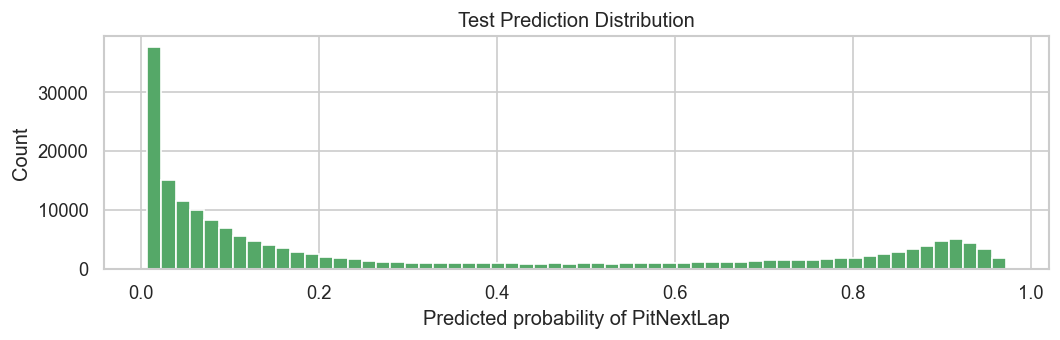

In [10]:
# Check test prediction distribution
print('Test prediction stats:')
print(pd.Series(test_preds).describe().round(4))

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(test_preds, bins=60, color='#55A868', edgecolor='white')
ax.set_title('Test Prediction Distribution')
ax.set_xlabel('Predicted probability of PitNextLap')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_preds
})

# Verify format matches sample submission
assert list(submission.columns) == list(sample_sub.columns), 'Column mismatch!'
assert len(submission) == len(sample_sub), f'Row count mismatch: {len(submission)} vs {len(sample_sub)}'
assert submission['PitNextLap'].between(0, 1).all(), 'Predictions out of [0,1] range!'

sub_path = SUBM_DIR / 'baseline_lgbm.csv'
submission.to_csv(sub_path, index=False)

print(f'Submission saved: {sub_path}')
print(f'Rows: {len(submission)}')
print(f'Prediction range: [{submission["PitNextLap"].min():.4f}, {submission["PitNextLap"].max():.4f}]')
print(f'Mean prediction:  {submission["PitNextLap"].mean():.4f}')
print()
print(submission.head(10))

Submission saved: submissions/baseline_lgbm.csv
Rows: 188165
Prediction range: [0.0066, 0.9721]
Mean prediction:  0.3126

       id  PitNextLap
0  439140      0.0406
1  439141      0.0552
2  439142      0.0367
3  439143      0.4641
4  439144      0.8858
5  439145      0.3659
6  439146      0.0602
7  439147      0.0247
8  439148      0.2225
9  439149      0.0261


## 8. Results Summary

In [13]:
print('=' * 50)
print('BASELINE RESULTS SUMMARY')
print('=' * 50)
print(f'Model:             LightGBM')
print(f'CV strategy:       GroupKFold(5) by Race+Year')
print(f'Features:          {len(FEATURES)}')
print(f'Train rows:        {len(train)}')
print(f'OOF AUC:           {overall_auc:.5f}')
print(f'OOF AUC (no 2023): {auc_non2023:.5f}')
print(f'Fold scores:       {[round(s,4) for s in fold_scores]}')
print(f'Fold std:          {np.std(fold_scores):.5f}')
print(f'Submission:        submissions/baseline_lgbm.csv')
print('=' * 50)

BASELINE RESULTS SUMMARY
Model:             LightGBM
CV strategy:       GroupKFold(5) by Race+Year
Features:          22
Train rows:        416326
OOF AUC:           0.92130
OOF AUC (no 2023): 0.88551
Fold scores:       [0.9047, 0.9316, 0.9122, 0.9391, 0.9226]
Fold std:          0.01249
Submission:        submissions/baseline_lgbm.csv
